# Clustering

This notebook contains the customer clustering process using the previously transformed and standardized RFM data. The K-Means algorithm is applied to identify customer segments based on their purchasing behavior and interaction patterns with the business.

The objective of this analysis is to uncover distinct customer groups with similar behavioral characteristics, allowing the business to better understand customer value, purchasing activity, and retention patterns. These segments can support data-driven marketing strategies, customer retention initiatives, and personalized business actions.

To perform the clustering process, the following RFM metrics were selected as features to represent customer behavior:

- Recency: Measures how recently a customer made a purchase. Lower recency values may indicate more active and engaged customers, while higher values may suggest inactivity or potential churn risk.

- Frequency: Represents how often a customer makes purchases within the analyzed period. Higher frequency values may indicate loyal customers or wholesale buyers with recurrent purchasing behavior.

- Monetary: Reflects the total amount spent by each customer during the analyzed period. This metric helps identify high-value customers and evaluate their overall contribution to the company’s revenue.

## Optimal number of clusters (Elbow Method)

Selecting an appropriate number of clusters is a critical step in the K-Means clustering process, as it directly affects the quality and interpretability of the resulting customer segments. Instead of choosing the number of clusters randomly, the Elbow Method is used to identify a suitable value of k based on the natural structure of the RFM data.

This method evaluates the Within-Cluster Sum of Squares (WCSS) across a range of k values. WCSS measures the total squared distance between data points and their corresponding cluster centroids. As the number of clusters increases, the WCSS value decreases because data points become closer to their assigned centroids.

The objective of the Elbow Method is to identify the point where the reduction in WCSS begins to slow down significantly, forming an “elbow” shape in the curve. This point represents a balance between minimizing cluster variance and avoiding unnecessary model complexity.

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

path = "../data_clean/rfm_scaled.csv"
df_rfm_scaled = pd.read_csv(path)

In [3]:
# Store WCSS values
wcss = []

# Range of k values to test
k_values = range(1, 11)

# Calculate WCSS for each k
for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)

    kmeans.fit(df_rfm_scaled)

    # Inertia = WCSS
    wcss.append(kmeans.inertia_)


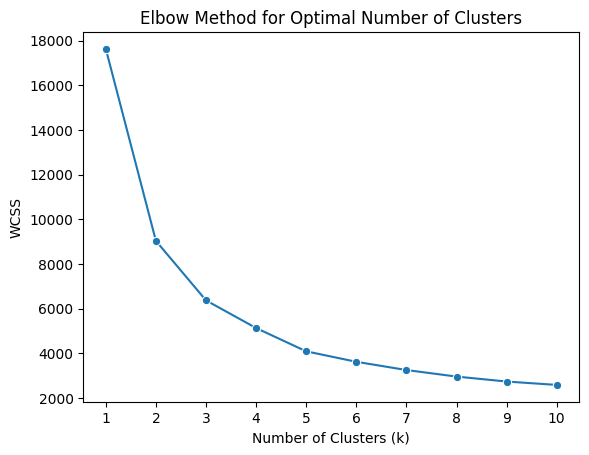

In [4]:
sns.lineplot(x=k_values, y=wcss, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.xticks(k_values)

plt.savefig("../figures/elbow_method.png")

plt.show()

### Insights and Results

The Elbow Method results show an abrupt reduction in WCSS between k=1 and k=4, indicating that increasing the number of clusters within this range significantly improves cluster compactness. However, after k=4, the rate of improvement begins to decrease progressively, suggesting diminishing returns from adding additional clusters.

Based on the observed inflection point in the curve, k=4 appears to provide an appropriate balance between cluster compactness and model simplicity. This result suggests that the customer base may naturally contain four distinguishable behavioral groups according to their RFM characteristics.

## Cluster Validation (Silhouette Score)

Although the Elbow Method provides a useful visual reference for selecting the number of clusters, an additional validation metric is required to evaluate the quality and separation of the generated clusters. For this purpose, the Silhouette Score is used as a complementary validation method.

The Silhouette Score measures how similar each data point is to its own cluster compared to other clusters. This metric combines both cluster cohesion and cluster separation, generating values that range from -1 to 1. Higher values indicate that observations are well grouped within their assigned clusters and clearly separated from neighboring clusters.

To validate the clustering structure, silhouette scores are calculated for multiple k values and compared through a line chart. This allows evaluating whether the selected number of clusters produces sufficiently distinct and meaningful customer segments.

In [5]:
from sklearn.metrics import silhouette_score

# Store silhouette scores
silhouette_scores = []

# Range of k values to test
k_values = range(2, 11)

# Compute silhouette score for each k
for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )

    cluster_labels = kmeans.fit_predict(df_rfm_scaled)

    score = silhouette_score(df_rfm_scaled, cluster_labels)

    silhouette_scores.append(score)

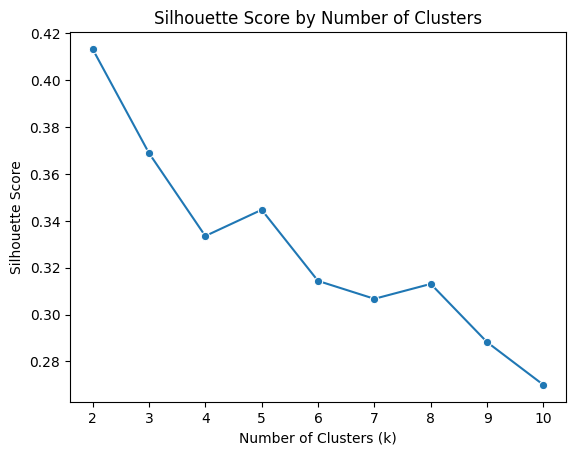

In [6]:
sns.lineplot(x=k_values, y=silhouette_scores, marker='o')
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.xticks(k_values)

plt.savefig("../figures/silhouette_score.png")

plt.show()

### Insights and Results

The silhouette analysis shows that the highest score is achieved when k=2, indicating strong separation between two broad customer groups. However, such segmentation would provide limited business interpretability, as it would likely oversimplify customer behavior patterns.

For k=4, the silhouette score remains within an acceptable range while still maintaining a balance between cluster separation and business interpretability. Additionally, the score difference between k=4 and neighboring values is not substantial, suggesting that the clustering structure remains relatively stable.

Considering the combined results from both the Elbow Method and Silhouette Analysis, k=4 was selected as the optimal number of clusters, as it provides interpretable and actionable customer segments while preserving an acceptable clustering quality.

## K-Means Implementation

Based on the results obtained from the Elbow Method and Silhouette Analysis, the K-Means clustering algorithm is applied using k=4 to generate customer segments according to their RFM behavioral patterns.

The model assigns each customer to one of the four clusters using the standardized Recency, Frequency, and Monetary features. This process enables the identification of customer groups with similar purchasing behaviors and overall value to the business.

In [7]:
# Initialize K-Means model
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

# Train model and assign cluster labels
cluster_labels = kmeans.fit_predict(df_rfm_scaled)

# Add cluster labels to original RFM table
df_rfm_scaled['Cluster'] = cluster_labels

# Display first rows
df_rfm_scaled.head()

,Recency,Frequency,Monetary,Cluster
0,0.595584,-0.311101,3.206230,0
1,-0.952279,1.050880,1.215998,0
2,-0.603532,-0.019927,0.573188,1
3,-0.871064,0.876801,1.139850,0
4,0.519146,-0.800178,-0.723025,2


In [8]:
cluster_count = df_rfm_scaled['Cluster'].value_counts().sort_index()
cluster_count

Cluster
0    1242
1    2058
2    1510
3    1068
Name: count, dtype: int64

/var/folders/r5/b9qqh1ss53s15l1z5h_ywhjr0000gn/T/ipykernel_3336/1075861483.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_count.index, y=cluster_count, palette=qual_palette)


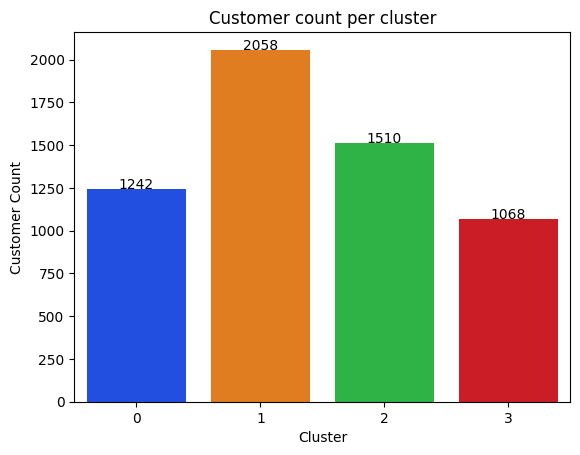

In [30]:
qual_palette = sns.color_palette("bright", 4)

sns.barplot(x=cluster_count.index, y=cluster_count, palette=qual_palette)
plt.title("Customer count per cluster")
plt.xlabel("Cluster")
plt.ylabel("Customer Count")

# Labels
for i, value in enumerate(cluster_count.values):
    plt.text(i, value + 1, f"{value}", ha='center')

plt.savefig("../figures/cluster_customer_count.png")
plt.show()

### Insights and Results

After the clustering process, the resulting customer distribution across clusters appears relatively balanced, suggesting that the selected number of clusters appropriately captures meaningful variations in customer behavior without generating excessively fragmented segments.

This result indicates that the clustering structure is sufficiently detailed to support business interpretation while remaining manageable for customer analysis and decision-making purposes. The generated segments will now be further analyzed to identify their behavioral characteristics and potential business value.

### Cluster Visualization and Final Observations

The following scatterplot visualizations illustrate the customer segmentation generated by the K-Means clustering model using the transformed and standardized RFM features. Additionally, the new df tht includes the cluster label for each customer will be saved for the business interpretation process.

In [10]:
# Save the data frame with cluster labels
df_rfm_scaled.to_csv("../data_clean/rfm_cluster.csv")

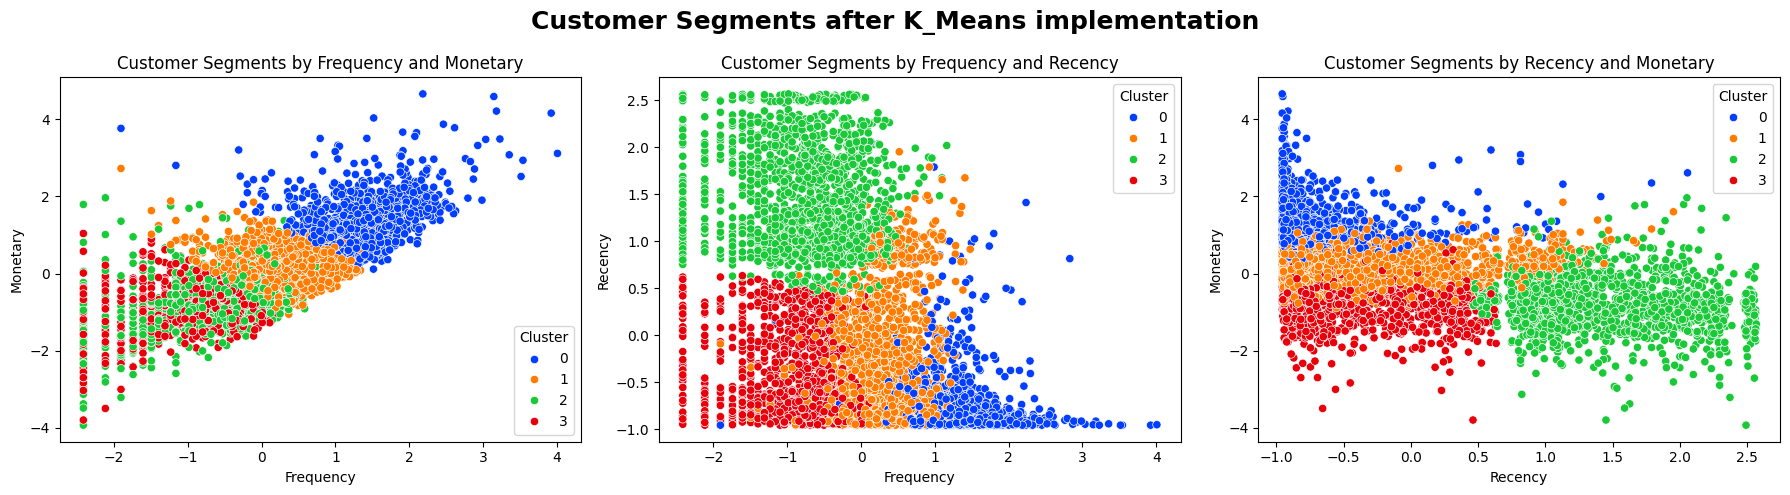

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(
    data=df_rfm_scaled,
    x='Frequency',
    y='Monetary',
    palette=qual_palette, 
    hue='Cluster', 
    ax=axes[0]
)

axes[0].set_title("Customer Segments by Frequency and Monetary")

sns.scatterplot(
    data=df_rfm_scaled,
    x='Frequency',
    y='Recency',
    palette=qual_palette, 
    hue='Cluster', 
    ax=axes[1]
)

axes[1].set_title("Customer Segments by Frequency and Recency")

sns.scatterplot(
    data=df_rfm_scaled,
    x='Recency',
    y='Monetary',
    palette=qual_palette, 
    hue='Cluster',
    ax=axes[2]
)

axes[2].set_title("Customer Segments by Recency and Monetary")

fig.suptitle("Customer Segments after K_Means implementation", fontsize=18, fontweight='bold')

plt.tight_layout()
plt.savefig("../figures/k-means_segments_3_angles.png")
plt.show()

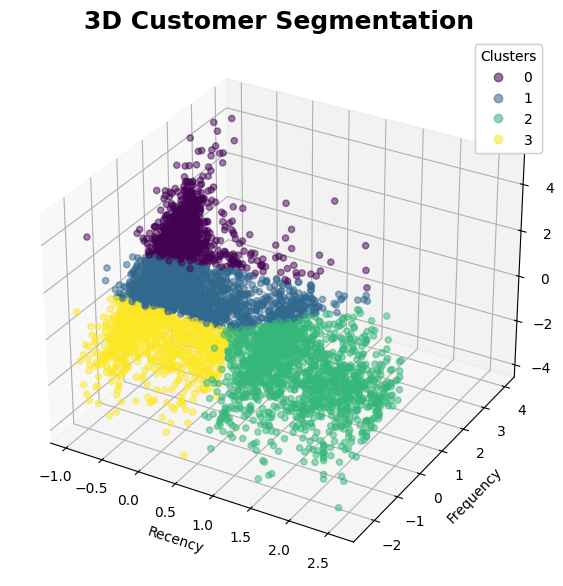

In [32]:
# Create figure
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

# Scatterplot
scatter = ax.scatter(
    df_rfm_scaled['Recency'],
    df_rfm_scaled['Frequency'],
    df_rfm_scaled['Monetary'],
    c=df_rfm_scaled['Cluster'],
    cmap='viridis',
    alpha=0.5
)

# Labels
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.title("3D Customer Segmentation", fontsize=18, fontweight='bold')

# Legend
legend = ax.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

ax.add_artist(legend)

plt.savefig("../figures/k-means_segments_3d.png")
plt.show()

Both the 2D and 3D representations show the different customer groups acording to the Recency, Frequency, and Monetary dimensions. Although some overlap exists between neighboring segments, the clustering structure reveals meaningful behavioral differences among customers.

These resulting segments will now be further analyzed from a business perspective to identify their characteristics, customer value, and potential strategic actions for marketing and customer retention purposes.